In [ ]:
!pip install tcia_utils pydicom torch matplotlib numpy
import torch
import numpy as np
import pydicom
import matplotlib.pyplot as plt
import os
from tcia_utils import nbia

In [ ]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


Normal image

In [ ]:
from PIL import Image
import requests
from io import BytesIO


# url = "https://sipi.usc.edu/database/download.php?vol=misc&img=5.1.12"
url = "https://sipi.usc.edu/database/download.php?vol=misc&img=4.1.07"
response = requests.get(url)
img = Image.open(BytesIO(response.content)).convert('RGB')  #Grayscale

# Convert to tensor and normalize
pixel_data = np.array(img).astype(np.float32) / 255.0
target_image = torch.tensor(pixel_data).permute(2, 0, 1).unsqueeze(0)
target_image = torch.nn.functional.interpolate(target_image, size=(256, 256), mode='bilinear')
target_image = target_image.squeeze(0)

MRI Load

In [ ]:
# data = nbia.getSeries(collection="UPENN-GBM")
# if data is None:
#     raise RuntimeError("UPENN-GBM returned no data.")
# print(f"'UPENN-GBM' returned {len(data)} series")

# nbia.downloadSeries(data, number=1, path="./brain_mri")

# # get middle slice
# dcm_files = []
# for root, dirs, files in os.walk("./brain_mri"):
#     for f in files:
#         if f.lower().endswith(".dcm"):
#             dcm_files.append(os.path.join(root, f))

# datasets = [pydicom.dcmread(f) for f in dcm_files]
# datasets.sort(key=lambda ds: ds.InstanceNumber)

# mid = len(datasets) // 2
# ds = datasets[mid]
# pixel_data = ds.pixel_array.astype(np.float32)

# if hasattr(ds, 'RescaleSlope'):
#     pixel_data = pixel_data * float(ds.RescaleSlope) + float(ds.RescaleIntercept)

# print(f"Loaded slice {mid+1}/{len(datasets)}, shape: {pixel_data.shape}")

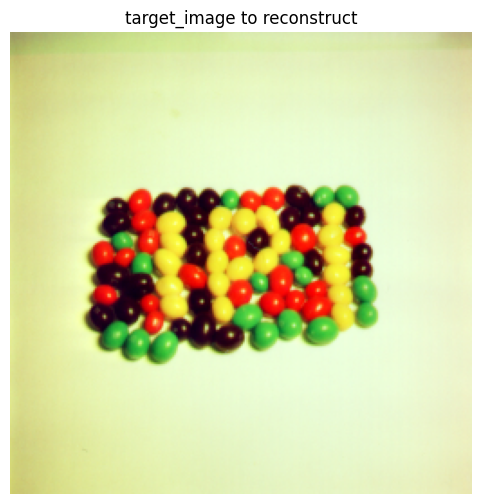

In [ ]:
# 1. Normalize and Clip
# Note: np.percentile on the whole array calculates global thresholds across RGB
p_low, p_high = np.percentile(pixel_data, (1, 99))
pixel_data = np.clip(pixel_data, p_low, p_high)
pixel_data = (pixel_data - p_low) / (p_high - p_low)

# 2. Prepare for Torch (H, W, C) -> (B, C, H, W)
target_image = torch.tensor(pixel_data).permute(2, 0, 1).unsqueeze(0)

# 3. Resize
target_image = torch.nn.functional.interpolate(target_image, size=(256, 256), mode='bilinear')

# 4. Prepare for Plotting (C, H, W) -> (H, W, C)
# Squeeze only the Batch dimension to keep the 3 color channels
target_image = target_image.squeeze(0)
# Rearrange back to H, W, C for Matplotlib
plot_image = target_image.permute(1, 2, 0).numpy()

# 5. Display
plt.figure(figsize=(6, 6))
plt.imshow(plot_image) # Removed cmap='gray'
plt.title("target_image to reconstruct")
plt.axis('off')
plt.show()

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

target_image = target_image.to(device)

k_full = torch.fft.fftshift(torch.fft.fft2(target_image))

mask = torch.zeros_like(k_full, dtype=torch.complex64)
center_h, center_w = k_full.shape[-2] // 2, k_full.shape[-1] // 2
dist = 128
mask[center_h - dist : center_h + dist, center_w - dist : center_w + dist] = 1

y_obs = k_full * mask

print(f"k_full shape: {k_full.shape}")
print(f"mask shape: {mask.shape}")
print(f"y_obs shape: {y_obs.shape}")

def ifft2(k_space_data):
    """Applies 2D inverse Fast Fourier Transform and returns the real part."""
    return torch.fft.ifft2(k_space_data).real

print("ifft2 function defined.")

Using device: cpu
k_full shape: torch.Size([3, 256, 256])
mask shape: torch.Size([3, 256, 256])
y_obs shape: torch.Size([3, 256, 256])
ifft2 function defined.


In [ ]:
# def tv_loss(x, eps=1e-6):
#     dx = x[1:, :] - x[:-1, :]      # [255, 256]
#     dy = x[:, 1:] - x[:, :-1]      # [256, 255]

#     dx = dx[:, :-1]                # → [255, 255]
#     dy = dy[:-1, :]                # → [255, 255]

#     return torch.mean(torch.sqrt(dx**2 + dy**2 + eps))
def tv_loss(x, eps=1e-6):
    # x is [3, 256, 256]
    # Calculate gradients across H and W for all channels
    dx = x[:, 1:, :] - x[:, :-1, :]
    dy = x[:, :, 1:] - x[:, :, :-1]

    # Square, sum across channels, then sqrt
    return torch.mean(torch.sqrt(dx[:, :, :-1]**2 + dy[:, :-1, :]**2 + eps))

In [ ]:
def create_kernel_basis(grid_size=256, num_kernels=16384, sigma=1.5):
    x = torch.linspace(0, grid_size, grid_size)
    y = torch.linspace(0, grid_size, grid_size)
    grid_x, grid_y = torch.meshgrid(x, y, indexing='ij')

    # centers_x = torch.randint(0, grid_size, (num_kernels,))
    # centers_y = torch.randint(0, grid_size, (num_kernels,))
    coords = torch.linspace(0, grid_size-1, int(np.sqrt(num_kernels)))
    centers_x, centers_y = torch.meshgrid(coords, coords, indexing='ij')
    centers_x = centers_x.flatten()
    centers_y = centers_y.flatten()


    basis = []
    for i in range(num_kernels):
        dist_sq = (grid_x - centers_x[i])**2 + (grid_y - centers_y[i])**2
        # Laplacian kernel: exp(-distance / sigma)
        kernel = torch.exp(-torch.sqrt(dist_sq) / sigma)
        basis.append(kernel.flatten())

    return torch.stack(basis).T  # [65536 x num_kernels]

Phi = create_kernel_basis()
print(f"Phi shape: {Phi.shape}")

Phi shape: torch.Size([65536, 16384])


In [ ]:

target_image = target_image.to(device)
# Use fftshift to move the low frequencies to the center before masking
k_full = torch.fft.fftshift(torch.fft.fft2(target_image))

mask = torch.zeros_like(k_full, dtype=torch.complex64)
center_h, center_w = k_full.shape[-2] // 2, k_full.shape[-1] // 2
dist = 128
mask[center_h - dist : center_h + dist, center_w - dist : center_w + dist] = 1

y_obs = k_full * mask

print(f"k_full shape: {k_full.shape}")
print(f"mask shape: {mask.shape}")
print(f"y_obs shape: {y_obs.shape}")

def ifft2(k_space_data):
    """Applies 2D inverse Fast Fourier Transform and returns the real part."""
    return torch.fft.ifft2(k_space_data).real

print("ifft2 function defined.")

k_full shape: torch.Size([3, 256, 256])
mask shape: torch.Size([3, 256, 256])
y_obs shape: torch.Size([3, 256, 256])
ifft2 function defined.


In [ ]:

num_kernels = Phi.shape[1]
c = (torch.randn(num_kernels, device=device) * 0.01).detach().requires_grad_(True)
learning_rate = .01
optimizer = torch.optim.Adam([c], lr=learning_rate)

print(f"Initialized coefficients 'c' with shape: {c.shape}")
print("Optimizer (Adam) initialized.")


Initialized coefficients 'c' with shape: torch.Size([16384])
Optimizer (Adam) initialized.


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Move everything first
Phi = Phi.to(device).float()
target_image = target_image.to(device)
mask = mask.to(device)

# Recompute k-space on device
k_full = torch.fft.fftshift(torch.fft.fft2(target_image))
y_obs = k_full * mask

# Initialize c ON DEVICE
num_kernels = Phi.shape[1]
c = (torch.randn(num_kernels, device=device) * 0.01).requires_grad_(True)

# Create optimizer AFTER moving c
optimizer = torch.optim.Adam([c], lr=0.01)

Using device: cpu


In [ ]:
loss_history = []
num_epocs = 10000

# 1. Initialize c as a MATRIX [num_kernels, 3] on the correct device
num_kernels = Phi.shape[1]
c = (torch.randn(num_kernels, 3, device=device) * 0.01).requires_grad_(True)

# 2. Initialize Optimizer FIRST
optimizer = torch.optim.Adam([c], lr=0.01)

# 3. Initialize Scheduler SECOND (it needs the optimizer as input)
scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer, step_size=2500, gamma=0.92
)

for epoch in range(num_epocs):
    optimizer.zero_grad()
    print(f"Epoch {epoch + 1}/{num_epocs}. + reached")

    # Generate image: (Phi @ c) results in [65536, 3]
    # Transpose and reshape to [3, 256, 256] for FFT
    x_recon = (Phi @ c).T.reshape(3, 256, 256)

    # Transform reconstruction to k-space
    k_recon = torch.fft.fftshift(torch.fft.fft2(x_recon))

    # Apply the mask
    y_recon = k_recon * mask

    # Loss calculation
    lambda_tv = 1e-4
    data_loss = torch.mean(torch.abs(y_recon - y_obs)**2)
    tv = tv_loss(x_recon)
    loss = data_loss + lambda_tv * tv

    # Optimization steps
    loss.backward()
    optimizer.step()
    scheduler.step()  # Now correctly follows optimizer.step()

    loss_history.append(loss.item())

    if (epoch + 1) % 100 == 0:
        print(f"Epoch {epoch + 1}/{num_epocs}, Data: {data_loss.item():.6f}, TV: {tv.item():.6f}")

Epoch 1/10000. + reached
Epoch 2/10000. + reached
Epoch 3/10000. + reached
Epoch 4/10000. + reached
Epoch 5/10000. + reached
Epoch 6/10000. + reached
Epoch 7/10000. + reached
Epoch 8/10000. + reached
Epoch 9/10000. + reached
Epoch 10/10000. + reached
Epoch 11/10000. + reached
Epoch 12/10000. + reached
Epoch 13/10000. + reached
Epoch 14/10000. + reached
Epoch 15/10000. + reached
Epoch 16/10000. + reached
Epoch 17/10000. + reached
Epoch 18/10000. + reached
Epoch 19/10000. + reached
Epoch 20/10000. + reached
Epoch 21/10000. + reached
Epoch 22/10000. + reached
Epoch 23/10000. + reached
Epoch 24/10000. + reached
Epoch 25/10000. + reached
Epoch 26/10000. + reached
Epoch 27/10000. + reached
Epoch 28/10000. + reached
Epoch 29/10000. + reached
Epoch 30/10000. + reached
Epoch 31/10000. + reached
Epoch 32/10000. + reached
Epoch 33/10000. + reached
Epoch 34/10000. + reached
Epoch 35/10000. + reached
Epoch 36/10000. + reached
Epoch 37/10000. + reached
Epoch 38/10000. + reached
Epoch 39/10000. + rea

In [ ]:
import matplotlib.pyplot as plt

# 1. Reshape the reconstruction to include 3 color channels
# Assuming Phi @ c results in a vector of size 256 * 256 * 3
reconstructed_image = (Phi @ c).reshape(256, 256, 3).cpu().detach().numpy()

# 2. Prepare the target image
# target_image is likely [3, 256, 256], so we permute to [256, 256, 3]
target_image_np = target_image.permute(1, 2, 0).cpu().detach().numpy()

# --- Visual Comparison: Original vs. Reconstructed ---
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
# Removed cmap='gray' so it displays in color
plt.imshow(target_image_np)
plt.title('Original Target Image')
plt.axis('off')

plt.subplot(1, 2, 2)
# Removed cmap='gray'
plt.imshow(reconstructed_image)
plt.title('Reconstructed Image')
plt.axis('off')

plt.tight_layout()
plt.show()

# --- Optimization Performance (This stays mostly the same) ---
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(loss_history)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss over Iterations (Linear Scale)')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.semilogy(loss_history)
plt.xlabel('Epoch')
plt.ylabel('Loss (Log Scale)')
plt.title('Loss over Iterations (Log Scale)')
plt.grid(True, which="both", ls="-", alpha=0.5)

plt.tight_layout()
plt.show()